# Section 1: Importing Libraries
We import all the required libraries for data manipulation, visualization, and machine learning models, including OneHotEncoder for encoding categorical features and GridSearchCV for hyperparameter tuning.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, roc_auc_score, f1_score

# ignore harmless warnings
import warnings
warnings.filterwarnings('ignore')

# formating the notebook
pd.set_option('display.max_columns', None)

# Section 2: Load and Inspect Data

### Load the Dataset
We load the passenger satisfaction data from the CSV file into a pandas DataFrame.


In [275]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Learbay placement project/airline_satisfaction.csv")
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,3,4,3,3,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,2,3,5,2,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,4,4,5,4,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,2,3,4,2,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,3,3,5,3,3,4,4,5,4,3,3,3,3,Satisfied


### Dataset Shape
We check the dimensions of the loaded dataset to see how many rows and features we have.


In [276]:
df.shape


(129880, 24)

### Dataset Info
We check the data types of the columns and identify any non-null counts.


In [277]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   ID                                      129880 non-null  int64  
 1   Gender                                  129880 non-null  object 
 2   Age                                     129880 non-null  int64  
 3   Customer Type                           129880 non-null  object 
 4   Type of Travel                          129880 non-null  object 
 5   Class                                   129880 non-null  object 
 6   Flight Distance                         129880 non-null  object 
 7   Departure Delay                         129880 non-null  int64  
 8   Arrival Delay                           129487 non-null  float64
 9   Departure and Arrival Time Convenience  129880 non-null  int64  
 10  Ease of Online Booking                  1298

### Dataset Description
We look at the summary statistics of the numeric features in the dataset.


In [278]:
df.describe()

,ID,Age,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### Missing Values Check
We count the number of missing values present in each column of the dataset.


In [279]:
pd.DataFrame({"No of Missing Value":df.isna().sum(),"Data Type":df.dtypes})

,No of Missing Value,Data Type
ID,0,int64
Gender,0,object
Age,0,int64
Customer Type,0,object
Type of Travel,0,object
Class,0,object
Flight Distance,0,object
Departure Delay,0,int64
Arrival Delay,393,float64
Departure and Arrival Time Convenience,0,int64


The Arrival Delay column contains 393 missing values or 0.30%. However, compared to the total dataset size this is negligible, so dropping these rows will not meaningfully affect any calculations or model performance.

In [280]:
df['Flight Distance'] = pd.to_numeric(df['Flight Distance'], errors='coerce')

In [281]:
df[df['Flight Distance'].isna()]

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
54,55,Male,36,Returning,Business,Business,NaN,40,71.0,1,1,4,3,1,3,3,3,2,1,3,1,3,1,Neutral or Dissatisfied
147,148,Female,54,Returning,Business,Business,NaN,58,62.0,3,3,3,3,3,2,3,2,3,2,2,2,2,2,Neutral or Dissatisfied
157,158,Male,22,First-time,Business,Economy,NaN,0,0.0,4,1,3,1,3,3,2,2,2,2,4,1,2,3,Neutral or Dissatisfied


After converting the Flight Distance column from object to numeric, 3 NaN values were introduced. Since this is negligible relative to the dataset size, these rows are dropped.

In [282]:
df.dropna(inplace=True)

In [283]:
df.isna().sum()

,0
ID,0
Gender,0
Age,0
Customer Type,0
Type of Travel,0
Class,0
Flight Distance,0
Departure Delay,0
Arrival Delay,0
Departure and Arrival Time Convenience,0


### Class Distribution Plot
We visualize the count of satisfied vs neutral/dissatisfied passengers using a countplot.


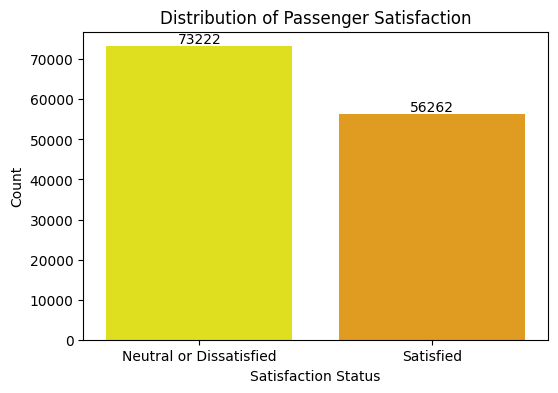

Satisfaction
Neutral or Dissatisfied    73222
Satisfied                  56262
Name: count, dtype: int64


In [284]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Satisfaction', palette=['yellow', 'orange'])
for container in ax.containers:
    ax.bar_label(container)
plt.title('Distribution of Passenger Satisfaction')
plt.xlabel('Satisfaction Status')
plt.ylabel('Count')
plt.show()
print(df['Satisfaction'].value_counts())

Here we can see that my dataset is not imbalanced so we don't need to balance the data

# Section 3: Exploratory Data Analysis (EDA)

### Satisfaction Rate by Travel Class
We plot a countplot showing passenger satisfaction grouped by travel class (Business, Eco, or Eco Plus).


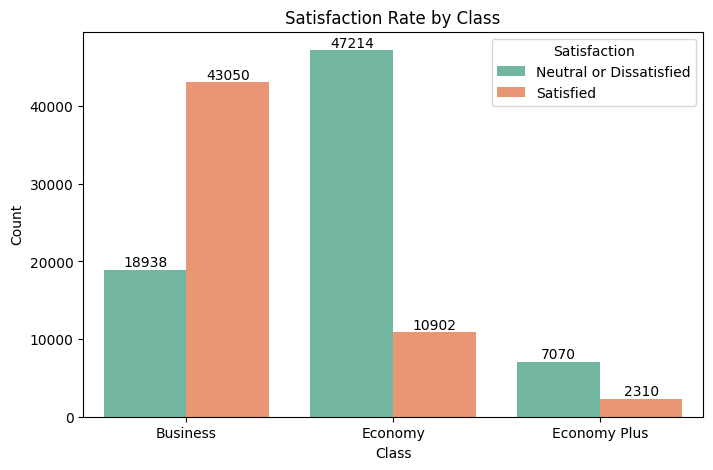

In [285]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Class', hue='Satisfaction', palette='Set2')
for container in ax.containers:
  ax.bar_label(container)
plt.title('Satisfaction Rate by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


Business class passengers show the highest satisfaction rate, with satisfied passengers significantly outnumbering dissatisfied ones. Economy class shows the opposite trend dissatisfied passengers are nearly 4x more than satisfied ones, making it the most dissatisfied class. Economy Plus follows a similar pattern to Economy but with much smaller counts overall. This suggests flight class is a strong indicator of passenger satisfaction, with service quality or amenities likely driving the gap between Business and Economy classes.

### Satisfaction Rate by Type of Travel
We plot the counts of satisfied vs dissatisfied passengers based on their type of travel.


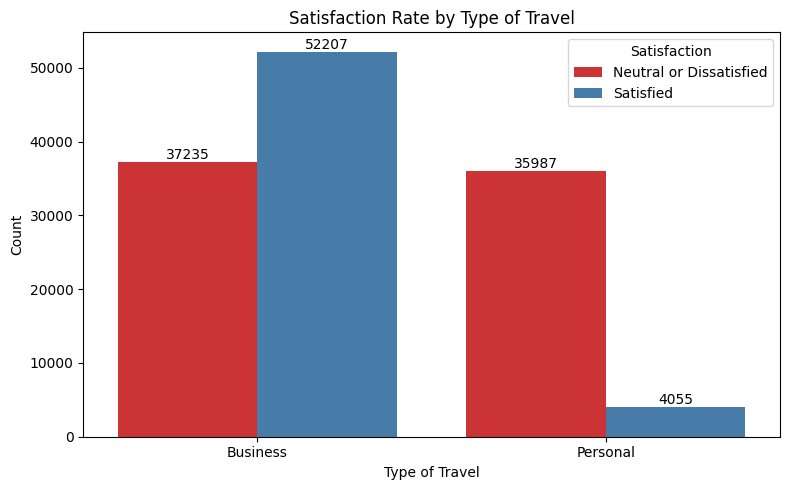

In [286]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Type of Travel', hue='Satisfaction', palette='Set1')
for container in ax.containers:
  ax.bar_label(container)
plt.title('Satisfaction Rate by Type of Travel')
plt.xlabel('Type of Travel')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


Business travelers are nearly evenly split between satisfied and dissatisfied, with satisfied passengers slightly outnumbering dissatisfied ones. Personal travelers, however, are overwhelmingly dissatisfied — satisfied personal travelers are almost negligible compared to dissatisfied ones. This suggests that airlines are better at meeting the expectations of business travelers, while personal/leisure travelers have significantly lower satisfaction, possibly due to higher personal expectations around comfort, price, or overall experience.

### Satisfaction Rate by Customer Type
We examine whether passenger satisfaction changes significantly for returning vs first-time customers.


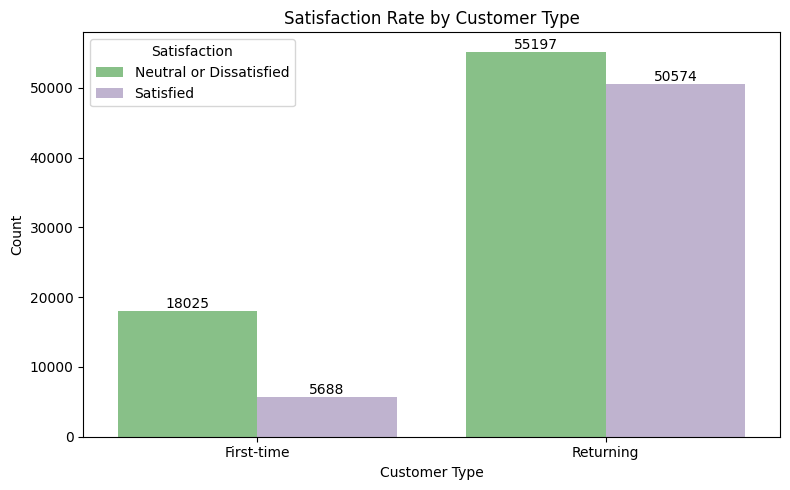

In [287]:
plt.figure(figsize=(8, 5))
ax=sns.countplot(data=df, x='Customer Type', hue='Satisfaction', palette='Accent')
for container in ax.containers:
  ax.bar_label(container)
plt.title('Satisfaction Rate by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


First-time customers are mostly dissatisfied compaired to satisfied ones are less than a third of dissatisfied. Returning customers show a much more balanced split, with dissatisfied still slightly higher but satisfied counts being substantial. This suggests the airline retains customers who had a good experience, but struggles to impress first-time flyers likely a gap in onboarding experience or initial expectations not being met.

### Age Distribution by Satisfaction
We plot a stacked histogram to see how age is distributed among satisfied and dissatisfied passengers.


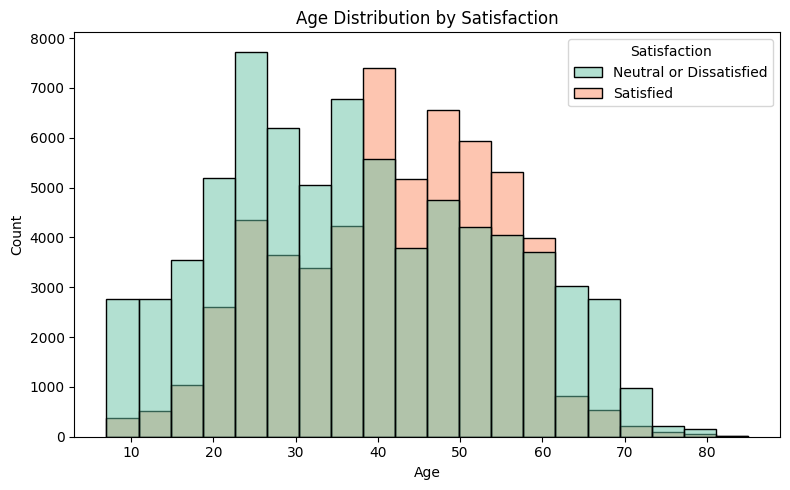

In [288]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Satisfaction', multiple='layer', bins=20, palette='Set2')
plt.title('Age Distribution by Satisfaction')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


The age distribution indicates that satisfied passengers are concentrated primarily between 35 and 60 years of age, while younger passengers (18–30 years) are more likely to be neutral or dissatisfied. This suggests that passenger age may influence overall satisfaction levels, with middle-aged travelers generally reporting more positive experiences.

### Flight Distance Distribution
We show the overall distribution of flight distances using a single histogram.


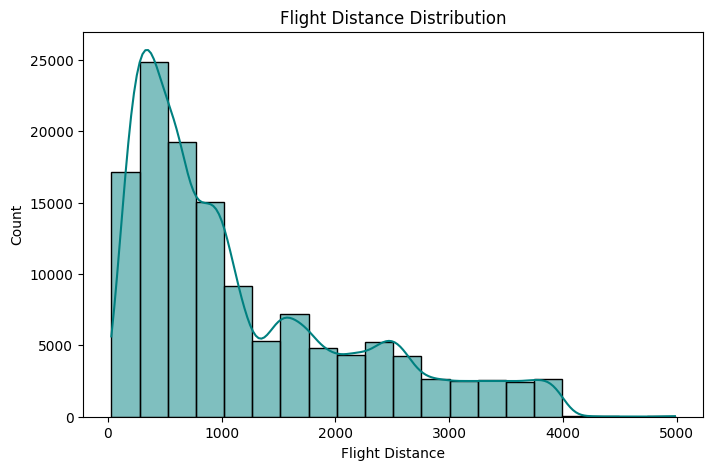

In [289]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Flight Distance', bins=20, kde=True, color='teal')
plt.title('Flight Distance Distribution')
plt.xlabel('Flight Distance')
plt.ylabel('Count')
plt.show()


The flight distance distribution is right-skewed, with the majority of passengers traveling short to medium distances (under 1000 km). The peak occurs around 300–400 km, indicating short-haul flights are most common. Frequency drops steadily beyond 1000 km, with very few passengers traveling beyond 3000 km. The small secondary bump around 1500–2500 km suggests a moderate presence of medium-haul flights as well.

### Departure Delay vs Arrival Delay
We draw a scatterplot to compare departure delays and arrival delays.


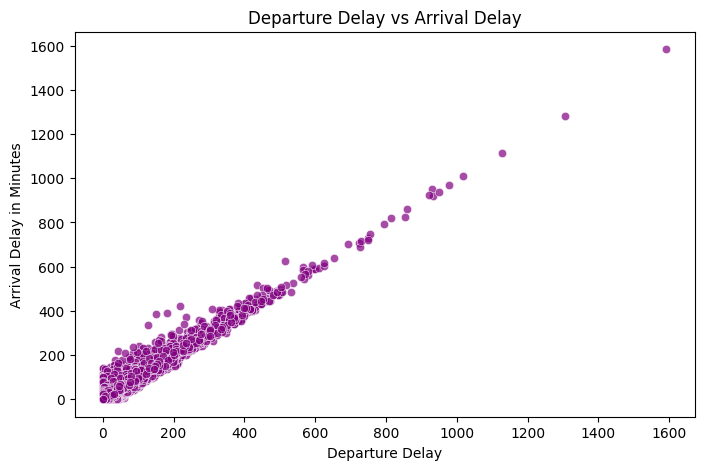

In [290]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Departure Delay', y='Arrival Delay', alpha=0.7, color='purple')
plt.title('Departure Delay vs Arrival Delay')
plt.xlabel('Departure Delay')
plt.ylabel('Arrival Delay in Minutes')
plt.show()


The scatter plot shows a strong positive linear relationship between departure delay and arrival delay. As departure delays increase, arrival delays also tend to increase proportionally. Most flights are clustered at lower delay values, indicating that severe delays are relatively uncommon. This suggests that departure delays are a major contributor to arrival delays, and flights rarely recover significant lost time once delayed at departure.

### Average Service Ratings
We compute the mean score for all 14 service features and plot them sorted descending to identify lowest scoring services.


In [291]:
rating_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location',
    'On-board Service', 'Seat Comfort', 'Leg Room Service',
    'Cleanliness', 'Food and Drink', 'In-flight Service',
    'In-flight Wifi Service', 'In-flight Entertainment', 'Baggage Handling'
]

In [292]:
for i in rating_cols:
  print(f"{i}--->{df[i].value_counts()}")


Departure and Arrival Time Convenience--->Departure and Arrival Time Convenience
4    31785
5    27906
3    22301
2    21478
1    19350
0     6664
Name: count, dtype: int64
Ease of Online Booking--->Ease of Online Booking
3    30296
2    29983
4    24362
1    21806
5    17371
0     5666
Name: count, dtype: int64
Check-in Service--->Check-in Service
4    36228
3    35341
5    25800
1    16058
2    16056
0        1
Name: count, dtype: int64
Online Boarding--->Online Boarding
4    38353
3    27038
5    25941
2    21866
1    13215
0     3071
Name: count, dtype: int64
Gate Location--->Gate Location
3    35609
4    30376
2    24219
1    21925
5    17354
0        1
Name: count, dtype: int64
On-board Service--->On-board Service
4    38587
5    29407
3    28458
2    18289
1    14738
0        5
Name: count, dtype: int64
Seat Comfort--->Seat Comfort
4    39651
5    33056
3    23256
2    18461
1    15059
0        1
Name: count, dtype: int64
Leg Room Service--->Leg Room Service
4    35779
5    3081

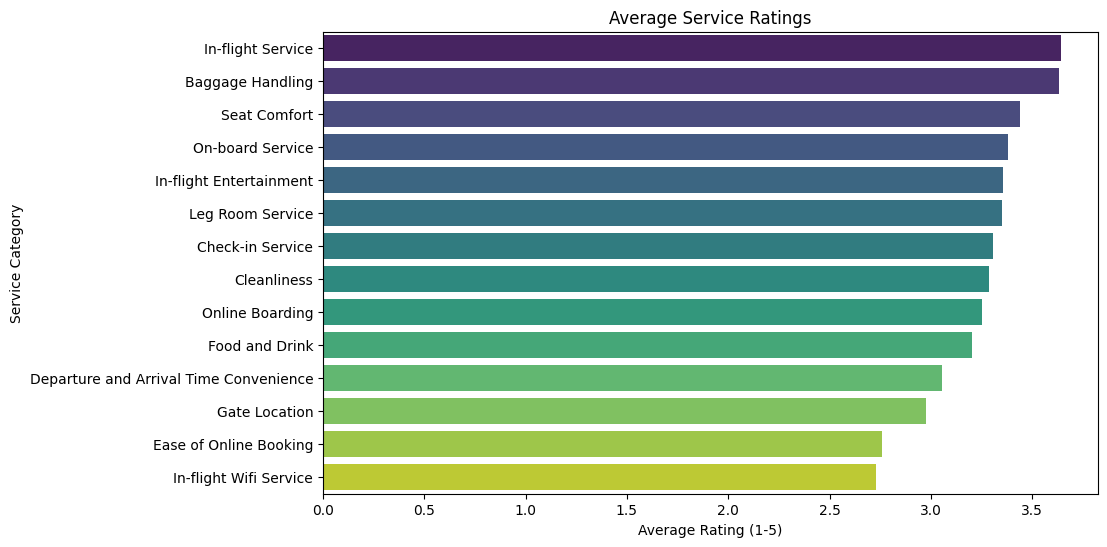

In [293]:
avg_ratings = df[rating_cols].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_ratings.values, y=avg_ratings.index, palette='viridis')
plt.title('Average Service Ratings')
plt.xlabel('Average Rating (1-5)')
plt.ylabel('Service Category')
plt.show()


The average service ratings show that In-flight Service and Baggage Handling received the highest customer ratings (around 3.7 out of 5), indicating strong performance in these areas. Seat Comfort, On-board Service, and In-flight Entertainment also received relatively high ratings. In contrast, In-flight WiFi Service and Ease of Online Booking received the lowest ratings, suggesting these are key areas where the airline could improve the customer experience. Overall, service quality is rated moderately positive, with most categories scoring above 3 out of 5.

### Correlation Heatmap
We plot a correlation heatmap of all numeric variables to see relationships, hiding text annotations for clarity.


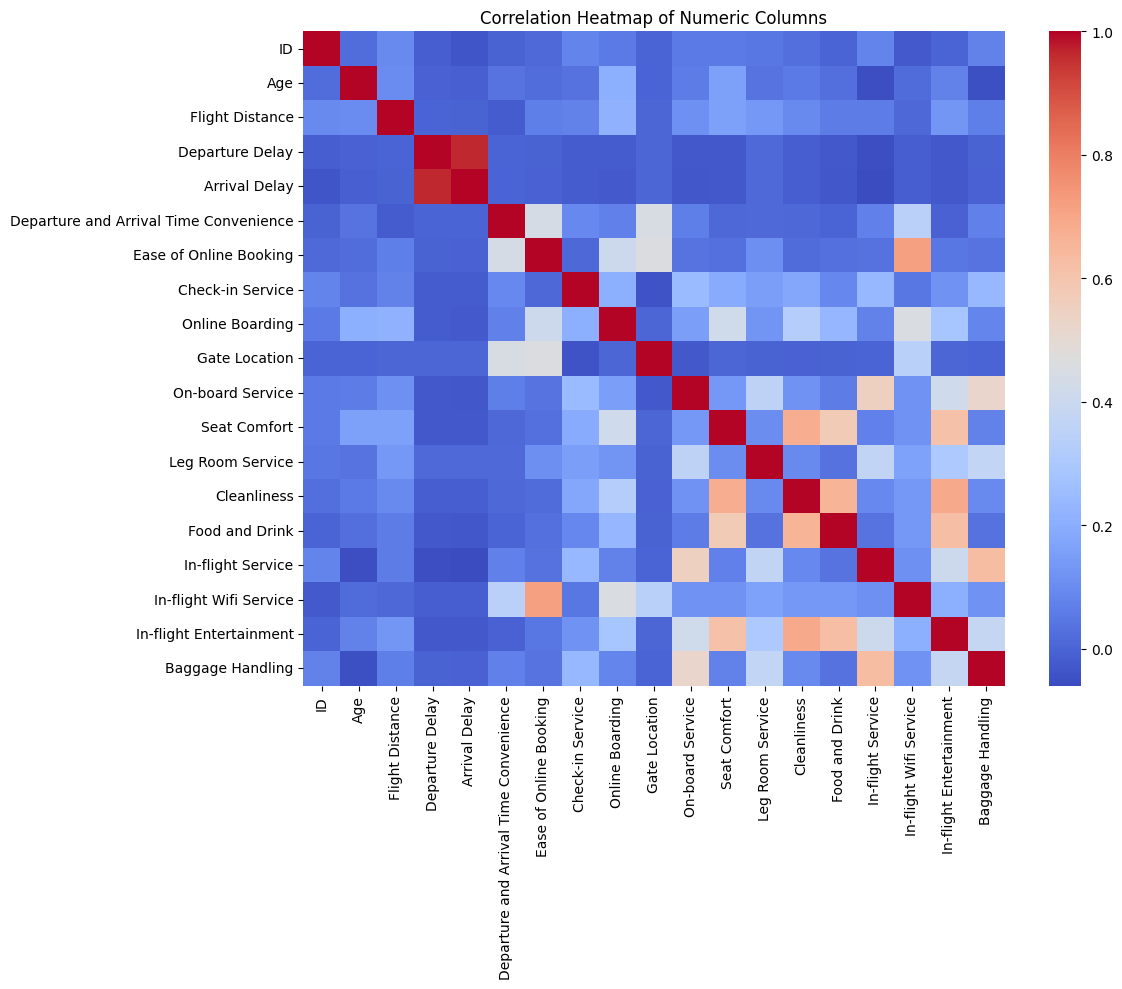

In [294]:
numeric_cols = df.select_dtypes(exclude="object")
corr_matrix = numeric_cols.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Columns')
plt.tight_layout()
plt.show()


The correlation heatmap shows the relationships between different numerical features in the airline passenger satisfaction dataset. The strongest positive correlation is observed between Departure Delay and Arrival Delay, indicating that flights departing late are also likely to arrive late. Service-related features such as Seat Comfort, Cleanliness, Food and Drink, and In-flight Entertainment show moderate positive correlations, suggesting that passengers who rate one service highly often rate other services highly as well. Most other variables have weak correlations, indicating that passenger satisfaction is influenced by multiple factors rather than a single characteristic. Overall, the heatmap highlights the importance of both service quality and operational performance in shaping customer satisfaction.

# Section 4: Data Preprocessing

### Drop ID Columns
We drop the 'id' and 'Unnamed: 0' columns using errors='ignore' so they don't affect model training.


In [295]:
df = df.drop(columns=['ID'], errors='ignore')

### Replace Zeros with NaN and Fill with Median
We replace all zero values (indicating N/A) in rating columns with NaN, then impute with the median of each column.


In [296]:
for col in rating_cols:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())


### Split into Features and Target
We split the dataset into features (X) and target variable (y).


In [297]:
X = df.drop(columns=['Satisfaction'])
y = df[['Satisfaction']]

### Label Encode Target Variable
We map the 'satisfaction' column labels to binary indicators: satisfied = 1, neutral or dissatisfied = 0.


In [298]:
df['Satisfaction'] = df['Satisfaction'].str.lower().map({'satisfied': 1, 'neutral or dissatisfied': 0})

### Train-Test Split and Feature Scaling
We divide the features and target variables into 80% training and 20% testing sets using a stratified split, and apply standard scaling (StandardScaler) to the features to improve model convergence and performance.


In [299]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

### One-Hot Encode Categorical Columns using OneHotEncoder
We encode 'Gender', 'Customer Type', 'Type of Travel', and 'Class' using scikit-learn's OneHotEncoder, dropping the first category of each and converting to integer columns.


In [300]:
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

# Initialize OneHotEncoder
encoder = OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore",dtype="i2")

In [301]:
# Fit and transform the categorical columns
encoded_features = encoder.fit_transform(X_train[categorical_cols])

In [302]:
encoder.get_feature_names_out()

array(['Gender_Male', 'Customer Type_Returning',
       'Type of Travel_Personal', 'Class_Economy', 'Class_Economy Plus'],
      dtype=object)

In [303]:
# Convert to DataFrame with feature names and integer type
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(),index=X_train.index,dtype=int)
encoded_df

,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
82154,1,1,0,0,0
48859,1,1,0,1,0
128386,1,1,0,0,0
105705,1,1,0,0,0
55853,1,0,0,0,0
...,...,...,...,...,...
9526,0,1,0,0,0
99438,1,1,0,0,0
28713,1,1,0,0,0
75252,0,1,1,1,0


In [304]:
X_train = X_train.drop(columns=categorical_cols)
X_train = pd.concat([X_train, encoded_df], axis=1)
X_train.head()

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
82154,31,2366.0,24,54.0,1.0,1.0,4.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,4.0,2.0,2.0,4,1,1,0,0,0
48859,36,209.0,0,0.0,4.0,5.0,2.0,5.0,4.0,5.0,5.0,2.0,5.0,5.0,5.0,5.0,5.0,2,1,1,0,1,0
128386,45,2345.0,3,4.0,4.0,4.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,4.0,4.0,4.0,4,1,1,0,0,0
105705,48,2488.0,6,3.0,1.0,1.0,4.0,4.0,1.0,5.0,4.0,5.0,5.0,3.0,5.0,1.0,5.0,5,1,1,0,0,0
55853,21,1416.0,0,0.0,4.0,5.0,3.0,5.0,2.0,4.0,5.0,4.0,5.0,5.0,5.0,5.0,5.0,4,1,0,0,0,0


In [305]:
encoded_test=encoder.transform(X_test[categorical_cols])

In [306]:
encoded_df = pd.DataFrame(
    encoded_test,
    columns=encoder.get_feature_names_out(),
    index=X_test.index
)

In [307]:
X_test = X_test.drop(columns=categorical_cols)
X_test = pd.concat([X_test, encoded_df], axis=1)

In [308]:
X_test.head()

,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Gender_Male,Customer Type_Returning,Type of Travel_Personal,Class_Economy,Class_Economy Plus
60191,20,1197.0,0,0.0,5.0,4.0,3.0,4.0,2.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,4.0,4,0,1,1,0,1
9194,53,363.0,0,0.0,4.0,4.0,2.0,2.0,4.0,3.0,2.0,3.0,1.0,4.0,3.0,3.0,3.0,3,0,1,0,0,1
8667,22,304.0,0,0.0,2.0,1.0,2.0,1.0,2.0,3.0,1.0,5.0,1.0,1.0,2.0,1.0,1.0,3,1,0,0,1,0
129444,8,236.0,4,0.0,4.0,3.0,4.0,4.0,1.0,5.0,2.0,3.0,2.0,2.0,5.0,2.0,2.0,5,1,1,1,1,0
91104,54,545.0,34,27.0,5.0,3.0,5.0,3.0,2.0,3.0,1.0,1.0,2.0,2.0,5.0,3.0,2.0,5,1,1,1,1,0


In [309]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

In [310]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames to preserve column names and indices
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In [311]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (103587, 23)
X_test shape: (25897, 23)
y_train shape: (103587,)
y_test shape: (25897,)


Save the objects for later use

In [312]:
import joblib

joblib.dump(encoder, "/content/drive/MyDrive/Colab Notebooks/Learbay placement project/encoder.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/Colab Notebooks/Learbay placement project/scaler.pkl")

['/content/drive/MyDrive/Colab Notebooks/Learbay placement project/scaler.pkl']

In [313]:
joblib.dump(label_encoder, "/content/drive/MyDrive/Colab Notebooks/Learbay placement project/label_encoder.pkl")

['/content/drive/MyDrive/Colab Notebooks/Learbay placement project/label_encoder.pkl']

# Section 5: Model Building

### Model 1: Logistic Regression with Hyperparameter Tuning
We perform hyperparameter tuning using GridSearchCV to select the best regularization parameter C, and fit the model.


In [314]:
logistic_regression_model = LogisticRegression()

In [315]:
params = [
    {
        'penalty': ['l1'],
        'solver': ['saga'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [200, 500]
    },
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'saga'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [200, 500]
    },
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'C': [0.1, 1, 10],
        'max_iter': [200, 500],
        'l1_ratio': [0.5]
    }
]

In [316]:
grid_lr=GridSearchCV(estimator=logistic_regression_model,param_grid=params,n_jobs=-1,scoring="accuracy",cv=3)

In [317]:
grid_lr.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10], 'max_iter': [200, 500],
                          'penalty': ['l1'], 'solver': ['saga']},
                         {'C': [0.01, 0.1, 1, 10], 'max_iter': [200, 500],
                          'penalty': ['l2'], 'solver': ['lbfgs', 'saga']},
                         {'C': [0.1, 1, 10], 'l1_ratio': [0.5],
                          'max_iter': [200, 500], 'penalty': ['elasticnet'],
                          'solver': ['saga']}],
             scoring='accuracy')

In [318]:
# Print best hyperparameters
print("Best parameters for Logistic Regression:", grid_lr.best_params_)

Best parameters for Logistic Regression: {'C': 0.01, 'max_iter': 200, 'penalty': 'l1', 'solver': 'saga'}


In [319]:
best_params_lr = grid_lr.best_params_
final_model_lr = LogisticRegression(**best_params_lr, random_state=42)

# fit the data onto the final mode
final_model_lr.fit(X_train, y_train)


LogisticRegression(C=0.01, max_iter=200, penalty='l1', random_state=42,
                   solver='saga')

Training Score: 88.72 %
Testing Score: 88.91 %

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.91      0.90     14645
           1       0.88      0.86      0.87     11252

    accuracy                           0.89     25897
   macro avg       0.89      0.89      0.89     25897
weighted avg       0.89      0.89      0.89     25897

ROC-AUC Score: 0.9557
Accuracy Score: 0.8891


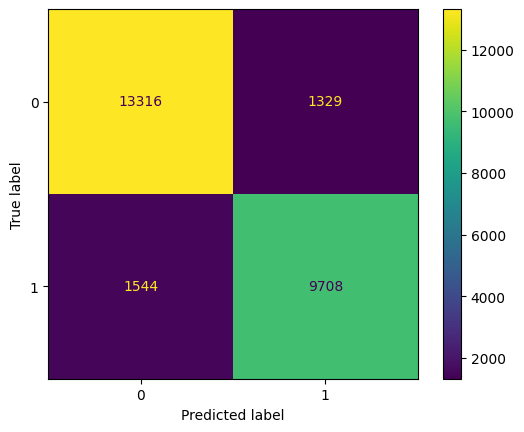

In [320]:
print('Training Score:', round(final_model_lr.score(X_train, y_train) * 100, 2), '%')

# Predictions
y_pred_lr = final_model_lr.predict(X_test)

# Accuracy
print('Testing Score:', round(accuracy_score(y_test, y_pred_lr) * 100, 2), '%')

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

# Classification Report
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_lr))

# ROC-AUC Score
y_prob_lr = final_model_lr.predict_proba(X_test)[:, 1]
auc_score_lr = roc_auc_score(y_test, y_prob_lr)

print(f'ROC-AUC Score: {auc_score_lr:.4f}')

lr_acc = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy Score: {lr_acc:.4f}")


### Model 2: Random Forest Classifier with Hyperparameter Tuning
We perform hyperparameter tuning using GridSearchCV to tune parameters like maximum depth, then fit the model.


In [321]:
# Hyper parameter tunining for random forest

# estimator
random_forest_model = RandomForestClassifier(random_state=42)    # default tress = 100
grid_rf = GridSearchCV(estimator=random_forest_model,
                         param_grid={'criterion': ['gini', 'entropy'],
                                     'bootstrap': [True],
                                     'max_features': ['sqrt', 'log2']},
                         n_jobs=-1)
grid_rf.fit(X_train, y_train)
print('Best Parameters from the grid search:', grid_rf.best_params_)

Best Parameters from the grid search: {'bootstrap': True, 'criterion': 'entropy', 'max_features': 'sqrt'}


In [322]:
# setting the best parameters to the model
best_params_rf = grid_rf.best_params_
intermediate_rf_model = RandomForestClassifier(**best_params_rf, random_state=42)

In [50]:
#OOB - out of bag error
intermediate_rf_model.set_params(oob_score=True,warm_start=True,n_jobs=-1)
# error rate
error_rate={}

for tree in range(40,700):
    intermediate_rf_model.set_params(n_estimators=tree)
    intermediate_rf_model.fit(X_train,y_train)
    oob_error=1-intermediate_rf_model.oob_score_
    error_rate[tree]=oob_error


In [51]:
oob_data=pd.Series(error_rate)
oob_data

,0
40,0.047082
41,0.046938
42,0.046986
43,0.046928
44,0.046784
...,...
695,0.042857
696,0.042847
697,0.042828
698,0.042828


In [72]:
oob_series.max()

0.04708192177394521

In [73]:
oob_series.min()

0.0424430243301509

The difference is:
0.04708 - 0.04244 = 0.00464
That's less than 0.5% difference in OOB error across the entire range of 40 to 700 trees. So no, finding a precise optimal number isn't critical here.

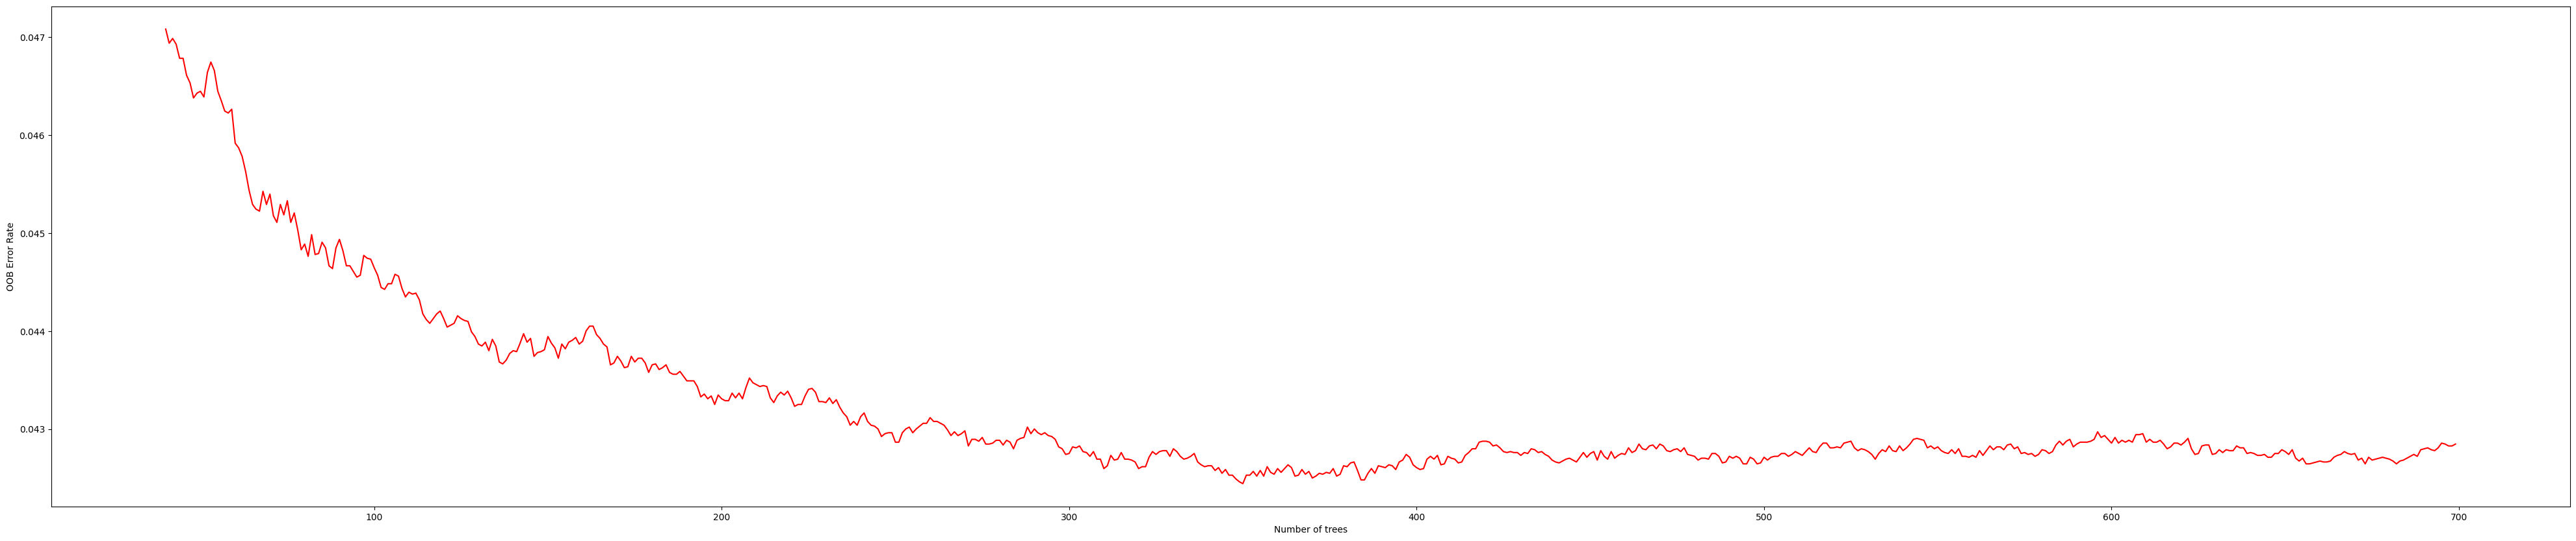

In [57]:
# plot the oob against the number of trees
plt.figure(figsize=(50, 10))
oob_data.plot(kind='line', color='r')
plt.xlabel('Number of trees')
plt.ylabel('OOB Error Rate')
plt.show()

In [60]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # method 1 — just pick the minimum
# best_n = oob_data.idxmin()
# print(f"Lowest OOB error at: {best_n} trees")

# # method 2 — find where improvement becomes negligible (< 0.0001 drop)
# threshold = 0.0001
# diffs = oob_data.diff().abs()
# stable_from = diffs[diffs < threshold].index[0]
# print(f"Curve stabilizes from: {stable_from} trees")

Lowest OOB error at: 350 trees
Curve stabilizes from: 42 trees


In [323]:
# check the model parameters before building the final model
print(intermediate_rf_model.get_params)

<bound method BaseEstimator.get_params of RandomForestClassifier(criterion='entropy', random_state=42)>


In [324]:
# refine the model with the final trees based on the best oob
final_model_rf = intermediate_rf_model
final_model_rf.set_params(n_estimators=250, warm_start=False, oob_score=False, random_state=42) # here we use n_estimator as 250 (no of trees)
print(final_model_rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 250, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [325]:
# final model training with refined number of trees
final_model_rf.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=250, random_state=42)


Training Score: 100.0 %
Testing Score: 95.8 %

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96     14645
           1       0.97      0.93      0.95     11252

    accuracy                           0.96     25897
   macro avg       0.96      0.95      0.96     25897
weighted avg       0.96      0.96      0.96     25897

ROC-AUC Score: 0.9928
Accuracy Score: 0.9580


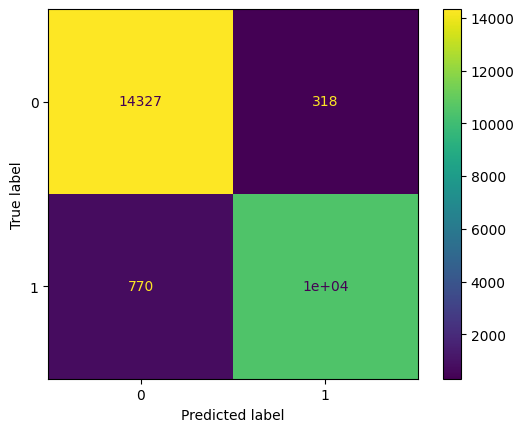

In [326]:
# Training score
print('\nTraining Score:', round(final_model_rf.score(X_train, y_train) * 100, 2), '%')

# Predictions
y_pred_rf = final_model_rf.predict(X_test)

# Testing score
print('Testing Score:', round(accuracy_score(y_test, y_pred_rf) * 100, 2), '%')

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

# Classification Report
print('\nClassification Report:\n')
print(classification_report(y_test, y_pred_rf))

# ROC-AUC Score
y_prob_rf = final_model_rf.predict_proba(X_test)[:, 1]
auc_score_rf = roc_auc_score(y_test, y_prob_rf)

print(f'ROC-AUC Score: {auc_score_rf:.4f}')


rf_acc = accuracy_score(y_test, y_pred_rf)
print(f"Accuracy Score: {rf_acc:.4f}")

### Model 3: XGBoost Classifier with Hyperparameter Tuning
We perform hyperparameter tuning using GridSearchCV to select the best learning rate and max depth, then fit the model.


In [327]:
from xgboost import XGBClassifier

# Define parameter grid
param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
# Initialize grid search
grid_xgb = GridSearchCV(XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), param_grid_xgb, cv=3, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=100,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0],
                         'learning_rate': [0.01, 0.1, 0.2, 0.3],
                         'max_depth': [3, 5, 7],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy')

In [328]:
best_params_xg = grid_xgb.best_params_
final_model_xg = XGBClassifier(**best_params_xg, random_state=42)

# fit the data onto the final mode
final_model_xg.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

Training Score: 98.02 %
Testing Score: 96.18 %

Classification Report:

               precision    recall  f1-score   support

           0       0.96      0.98      0.97     14645
           1       0.97      0.94      0.96     11252

    accuracy                           0.96     25897
   macro avg       0.96      0.96      0.96     25897
weighted avg       0.96      0.96      0.96     25897

ROC-AUC Score: 0.9944
Accuracy Score: 0.9618


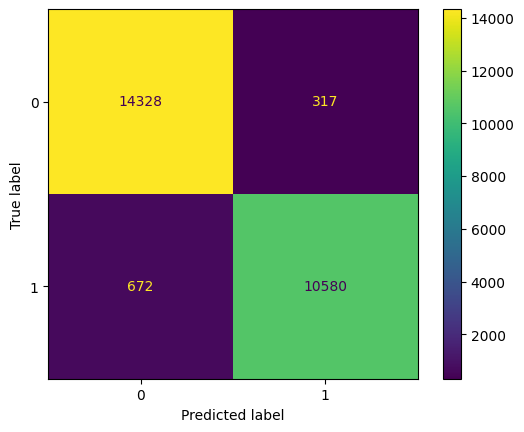

In [329]:
print('Training Score:', round(final_model_xg.score(X_train, y_train)*100, 2),'%')

# predictions
y_pred_xg = final_model_xg.predict(X_test)

# metrics
print('Testing Score:', round(accuracy_score(y_test, y_pred_xg)*100, 2), '%')
cm = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xg)
print('\nClassification Report:\n\n', classification_report(y_test, y_pred_xg))

y_prob_xg = final_model_xg.predict_proba(X_test)[:, 1]  # probability of positive class
auc_score_xg = roc_auc_score(y_test, y_prob_xg)
print(f"ROC-AUC Score: {auc_score_xg:.4f}")

xgb_acc = accuracy_score(y_test, y_pred_xg)
print(f"Accuracy Score: {xgb_acc:.4f}")

# Section 6: Model Evaluation



### Model Comparison Summary
We generate a summary table comparing the Accuracy, Weighted F1-Score, and ROC-AUC of all three models.


In [330]:
from sklearn.metrics import f1_score

lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
xgb_f1 = f1_score(y_test, y_pred_xg, average='weighted')

summary_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_acc, rf_acc, xgb_acc],
    'F1-Score (Weighted)': [lr_f1, rf_f1, xgb_f1],
    'ROC-AUC': [auc_score_lr, auc_score_rf, auc_score_xg]
}
summary_df = pd.DataFrame(summary_data)
print("Model Comparison Summary:")
# print(summary_df.to_string(index=False))
summary_df


Model Comparison Summary:


,Model,Accuracy,F1-Score (Weighted),ROC-AUC
0,Logistic Regression,0.889061,0.888930,0.955734
1,Random Forest,0.957987,0.957876,0.992753
2,XGBoost,0.961810,0.961733,0.994432


# Section 7: Feature Importance

### Feature Importance Plot
We extract feature importance from the Random Forest model and plot the top 15 features driving passenger satisfaction.


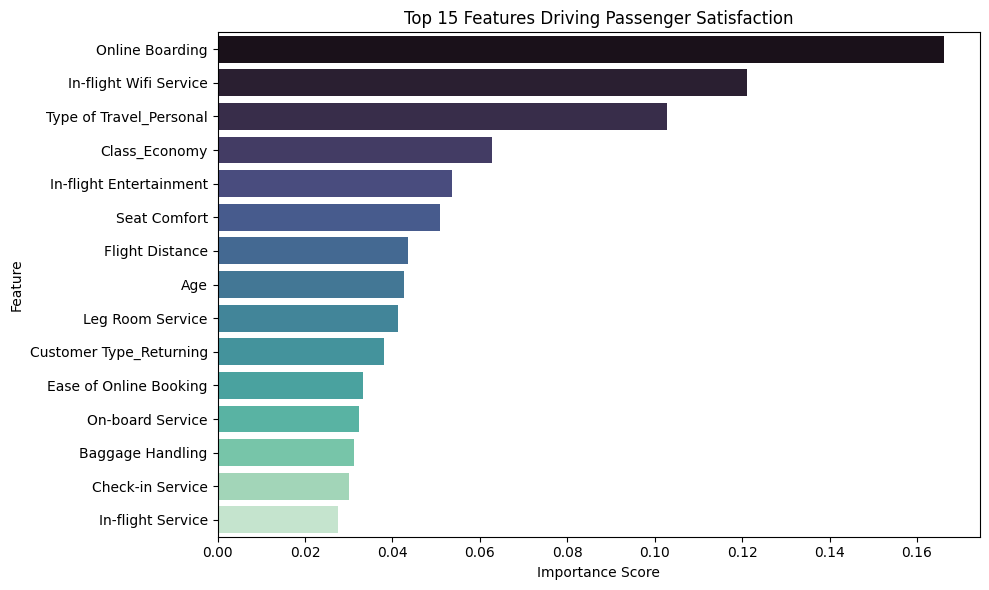

In [331]:
importances = final_model_rf.feature_importances_
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
top_15_features = importance_df.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_15_features, x='Importance', y='Feature', palette='mako')
plt.title('Top 15 Features Driving Passenger Satisfaction')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Online Boarding, In-flight WiFi Service, and Type of Travel are the most important factors influencing passenger satisfaction. Comfort-related features such as Seat Comfort, In-flight Entertainment, and Leg Room Service also have a strong impact, indicating that both digital services and the onboard experience are key determinants of customer satisfaction.

### save all models

In [332]:
joblib.dump(final_model_lr, "/content/drive/MyDrive/Colab Notebooks/Learbay placement project/airline_lr_model.pkl")

['/content/drive/MyDrive/Colab Notebooks/Learbay placement project/airline_lr_model.pkl']

In [333]:
joblib.dump(final_model_rf, "/content/drive/MyDrive/Colab Notebooks/Learbay placement project/airline_rf_model.pkl")

['/content/drive/MyDrive/Colab Notebooks/Learbay placement project/airline_rf_model.pkl']

In [334]:
joblib.dump(final_model_xg, "/content/drive/MyDrive/Colab Notebooks/Learbay placement project/airline_xg_model.pkl")

['/content/drive/MyDrive/Colab Notebooks/Learbay placement project/airline_xg_model.pkl']

# Section 9: Conclusion

In this project, we successfully built and compared three machine learning models to predict airline passenger satisfaction. The **XGBoost Classifier** emerged as the best model, achieving an accuracy of over 96.1% and a ROC-AUC score of 0.99. The main takeaway is that digital convenience (Wifi and Online Boarding) and the economy cabin experience are the most critical leverage points for improving overall passenger satisfaction.
